# Bayesian Panel VAR Tutorial

This tutorial introduces the `BayesianPanelVAR` class in `MacroPy` using the hierarchical panel VAR example adapted from the MATLAB code shared by **Haroon Mumtaz**.

The processed dataset in `../datasets/PVAR_Data.csv` contains:

- `g_rgdp`: $100 \times \Delta \log(\mathrm{RGDP})$
- `g_cpi`: $100 \times \Delta \log(\mathrm{CPI})$
- `sti`: short-term interest rate in levels
- `g_oil`, `g_gas`: common exogenous variables, both in $100 \times \Delta \log(\cdot)$

The panel contains four euro-area countries (`de`, `fr`, `it`, `es`) observed quarterly.

In [23]:
import numpy as np
import pandas as pd

panel = pd.read_csv("../datasets/PVAR_Data.csv", parse_dates=["date"])
panel.head()

,date,unit,g_rgdp,g_cpi,sti,g_oil,g_gas
0,1960-06-30,de,1.601640,0.569339,5.879200,0.000000,0.000000
1,1960-09-30,de,5.193637,0.000000,6.597193,0.000000,0.000000
2,1960-12-31,de,-0.234506,0.283458,6.569367,0.000000,0.000000
3,1961-03-31,de,0.625118,0.925746,5.229362,-3.750447,3.295585
4,1961-06-30,de,-0.703254,0.758335,4.287881,0.000000,0.000000


## 1. Expected Panel Format

`BayesianPanelVAR` expects a **balanced long-format panel** with:

- one column identifying the unit (`unit`)
- one datetime column identifying time (`date`)
- one column per endogenous variable
- optional common exogenous variables repeated across units for each time period

In [12]:
panel.groupby("unit").size().rename("observations")

unit
de    227
es    227
fr    227
it    227
Name: observations, dtype: int64

In [ ]:
from MacroPy import BayesianPanelVAR

bpvar = BayesianPanelVAR(
    data=panel,
    endog=["g_rgdp", "g_cpi", "sti"],
    exog=["g_oil", "g_gas"],
    unit_col="unit",
    time_col="date",
    lags=4,
    post_draws=10000,
    burnin=0.5,
    hor=24,
    fhor=12,
)

bpvar.model_summary()


**MacroPy: A Toolbox for Bayesian Macroeconometric Analysis in Python**  
Developed by [Renato Vassallo](https://www.linkedin.com/in/renatovassallo) - Institute for Economic Analysis (IAE-CSIC)  
Version 0.1.5 - July 2025  

---

**Model Specifications**  
- **Model Type**: Bayesian Panel VAR
- **Endogenous Variables**: g_rgdp, g_cpi, sti
- **Exogenous Variables**: Constant, g_oil, g_gas
- **Number of Lags**: 4
- **Sample Period**: 1961-06-30 to 2016-12-31 (223 observations per unit)

- **Panel Units**: de, es, fr, it
- **Number of Units**: 4
- **Total Parameters Estimated**: 217

---

**Bayesian Estimation Settings**
- **Posterior Simulation**: Gibbs Sampling
- **Prior Type**: Hierarchical Minnesota Pooling
- **Total Draws**: 10000
- **Burn-in**: 5000 (50%)
- **Hierarchical Pooling Parameter**: lambda

---

**Forecast & IRF Details**
- **Impulse Response Horizon**: 24
- **Forecast Horizon**: 12
- **IRF Computation**: 1 Standard Deviation

---

**Model Equations**

$$

\begin{align*}
y_{u,t} &= \sum_{\ell=1}^{p} A_{u,\ell} y_{u,t-\ell} + C_{u} x_t + e_{u,t},
\qquad e_{u,t} \sim \mathcal{N}(0, \Sigma_u) \\
\beta_u &= \mathrm{vec}\left(A_{u,1}, \ldots, A_{u,p}\right) \\
\beta_u &\sim \mathcal{N}\!\left(\bar{\beta}, \lambda \Omega_u\right)
\end{align*}

$$


## 2. Visualizing One Unit

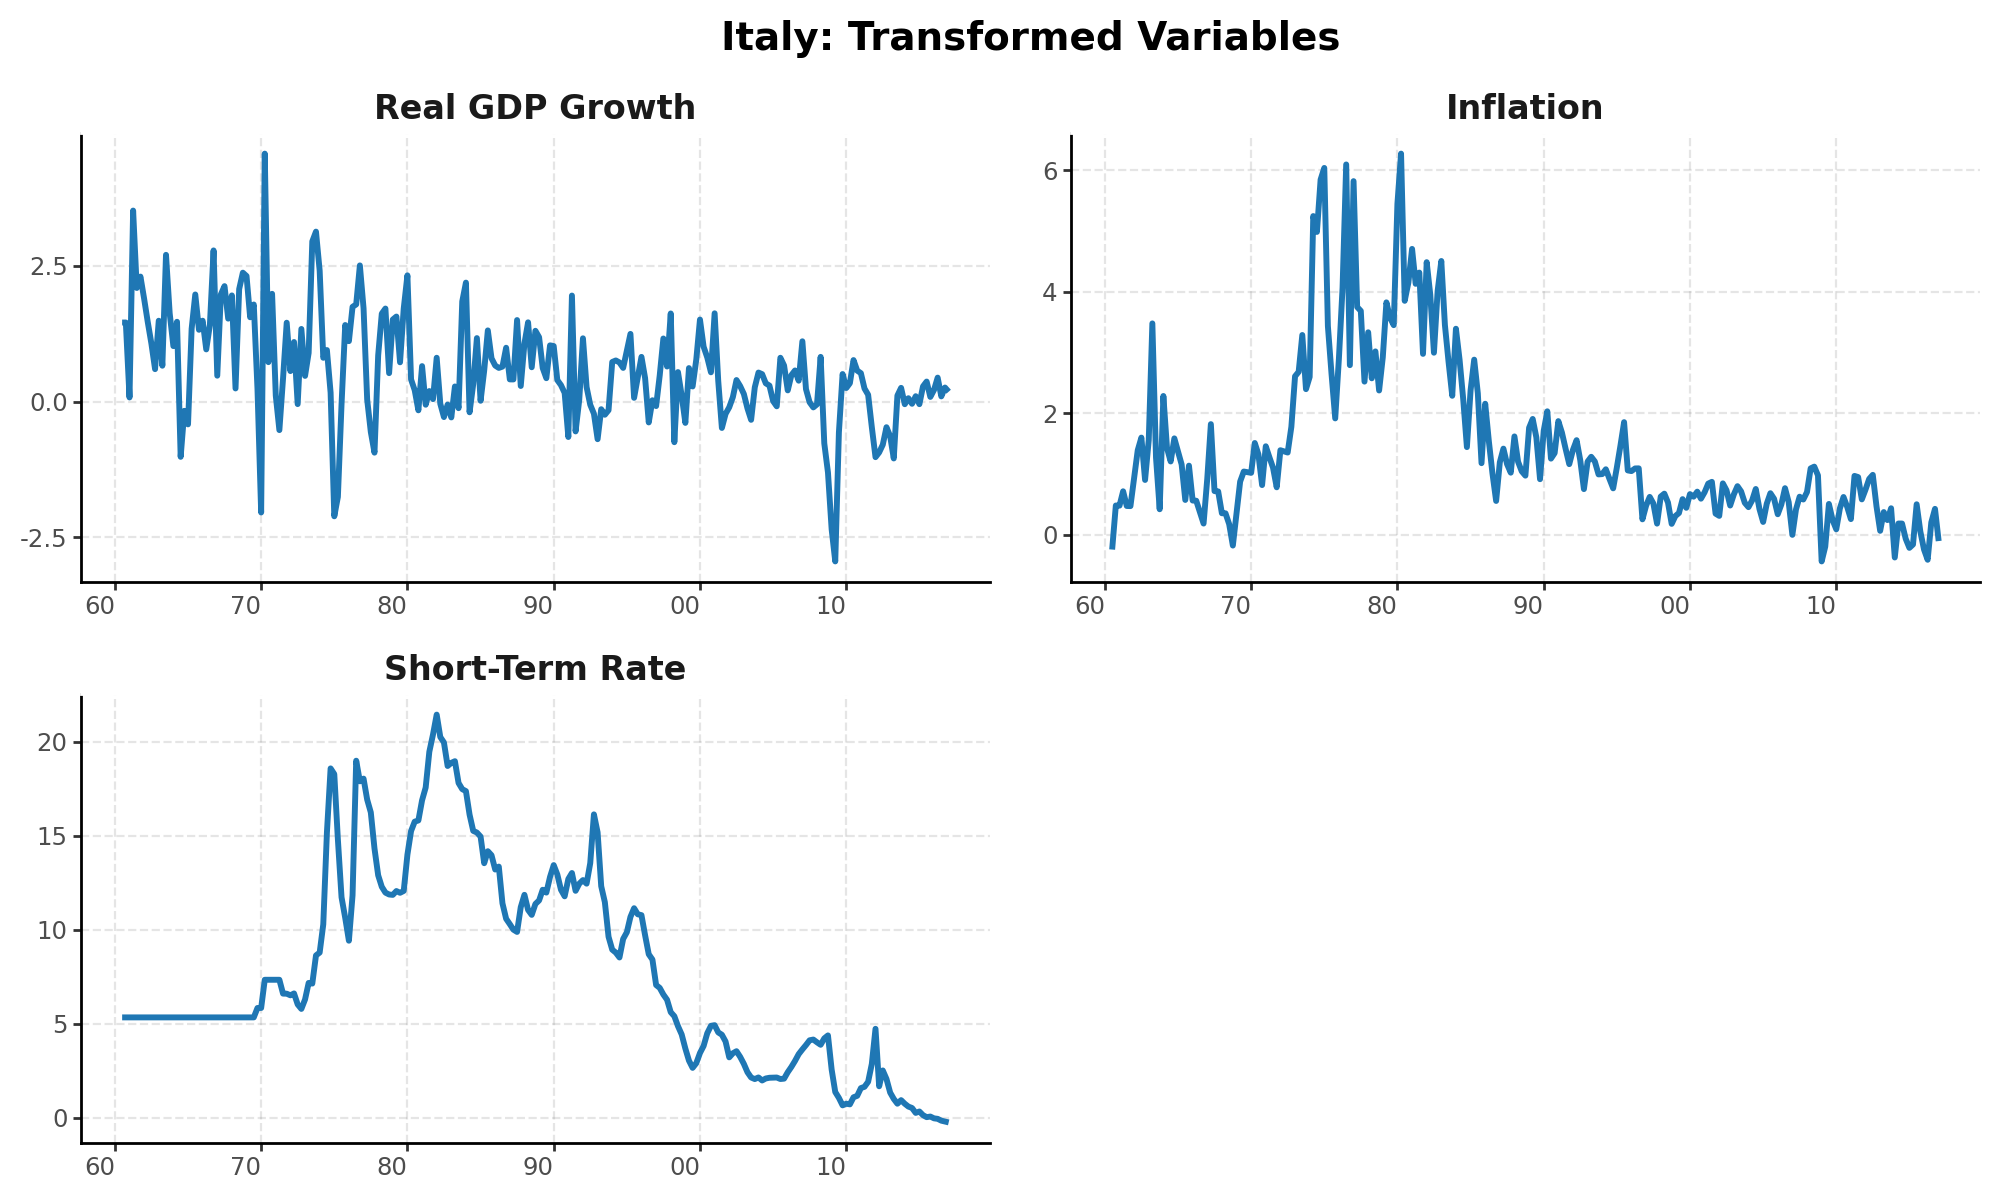

In [14]:
bpvar.plot_unit_series(
    "it",
    series_titles=["Real GDP Growth", "Inflation", "Short-Term Rate"],
    title="Italy: Transformed Variables",
)

## 3. Posterior Sampling

In [15]:
posterior = bpvar.sample_posterior(plot_coefficients=False)

{
    "beta_draws": posterior["beta_draws"].shape,
    "c_draws": posterior["c_draws"].shape,
    "Sigma_draws": posterior["Sigma_draws"].shape,
    "bbar_draws": posterior["bbar_draws"].shape,
    "lambda_draws": posterior["lambda_draws"].shape,
}

Sampling Panel Posterior: 100%|██████████| 10000/10000 [00:07<00:00, 1349.07it/s]


{'beta_draws': (5000, 4, 36),
 'c_draws': (5000, 4, 9),
 'Sigma_draws': (5000, 4, 3, 3),
 'bbar_draws': (5000, 36),
 'lambda_draws': (5000,)}

In [16]:
pd.Series(posterior["lambda_draws"], name="lambda").describe()

count    5000.000000
mean        0.066480
std         0.015192
min         0.024760
25%         0.055721
50%         0.065168
75%         0.075664
max         0.137666
Name: lambda, dtype: float64

## 4. Unit-Specific IRFs

Computing Panel IRFs: 100%|██████████| 5000/5000 [00:08<00:00, 599.19it/s]


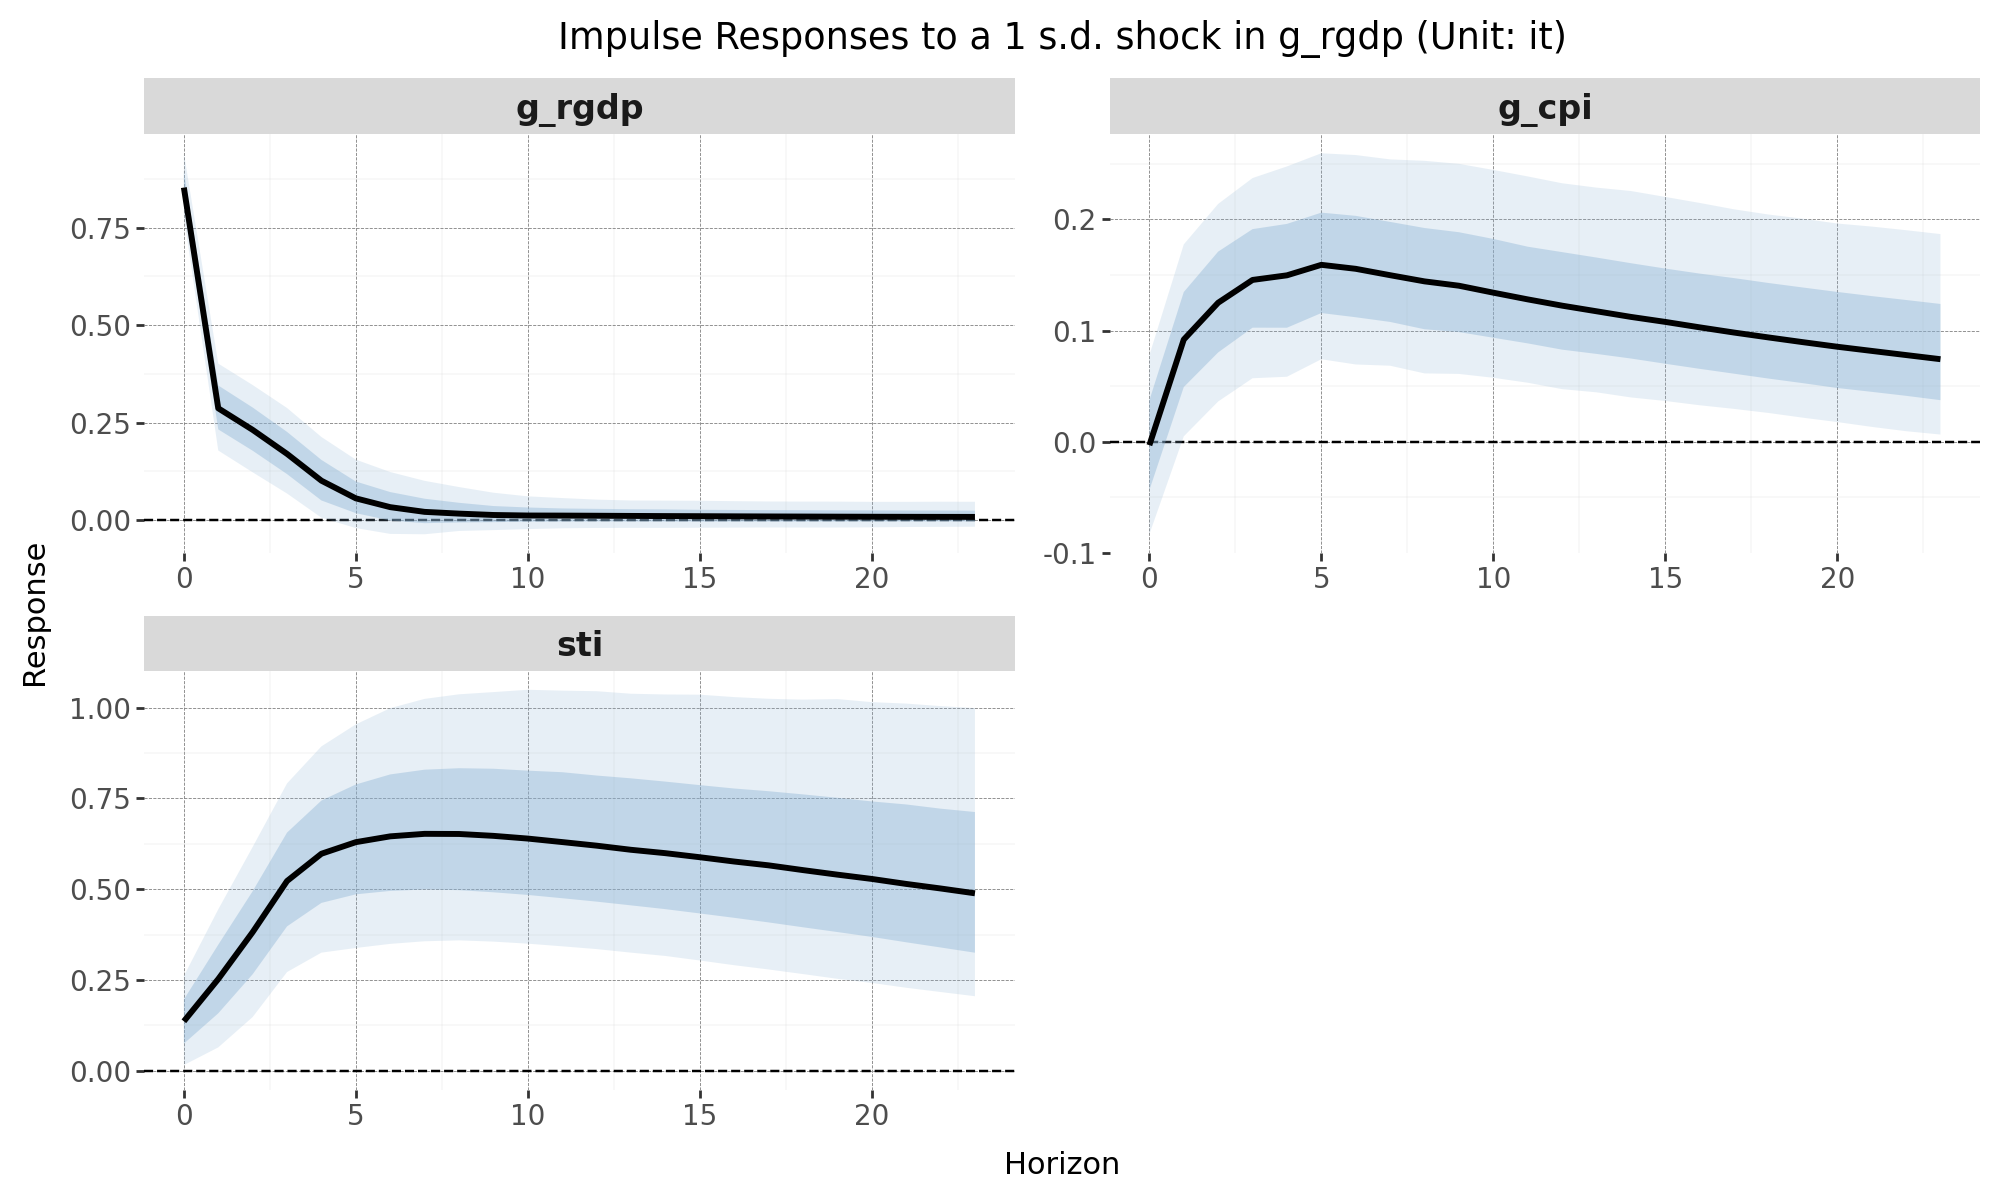

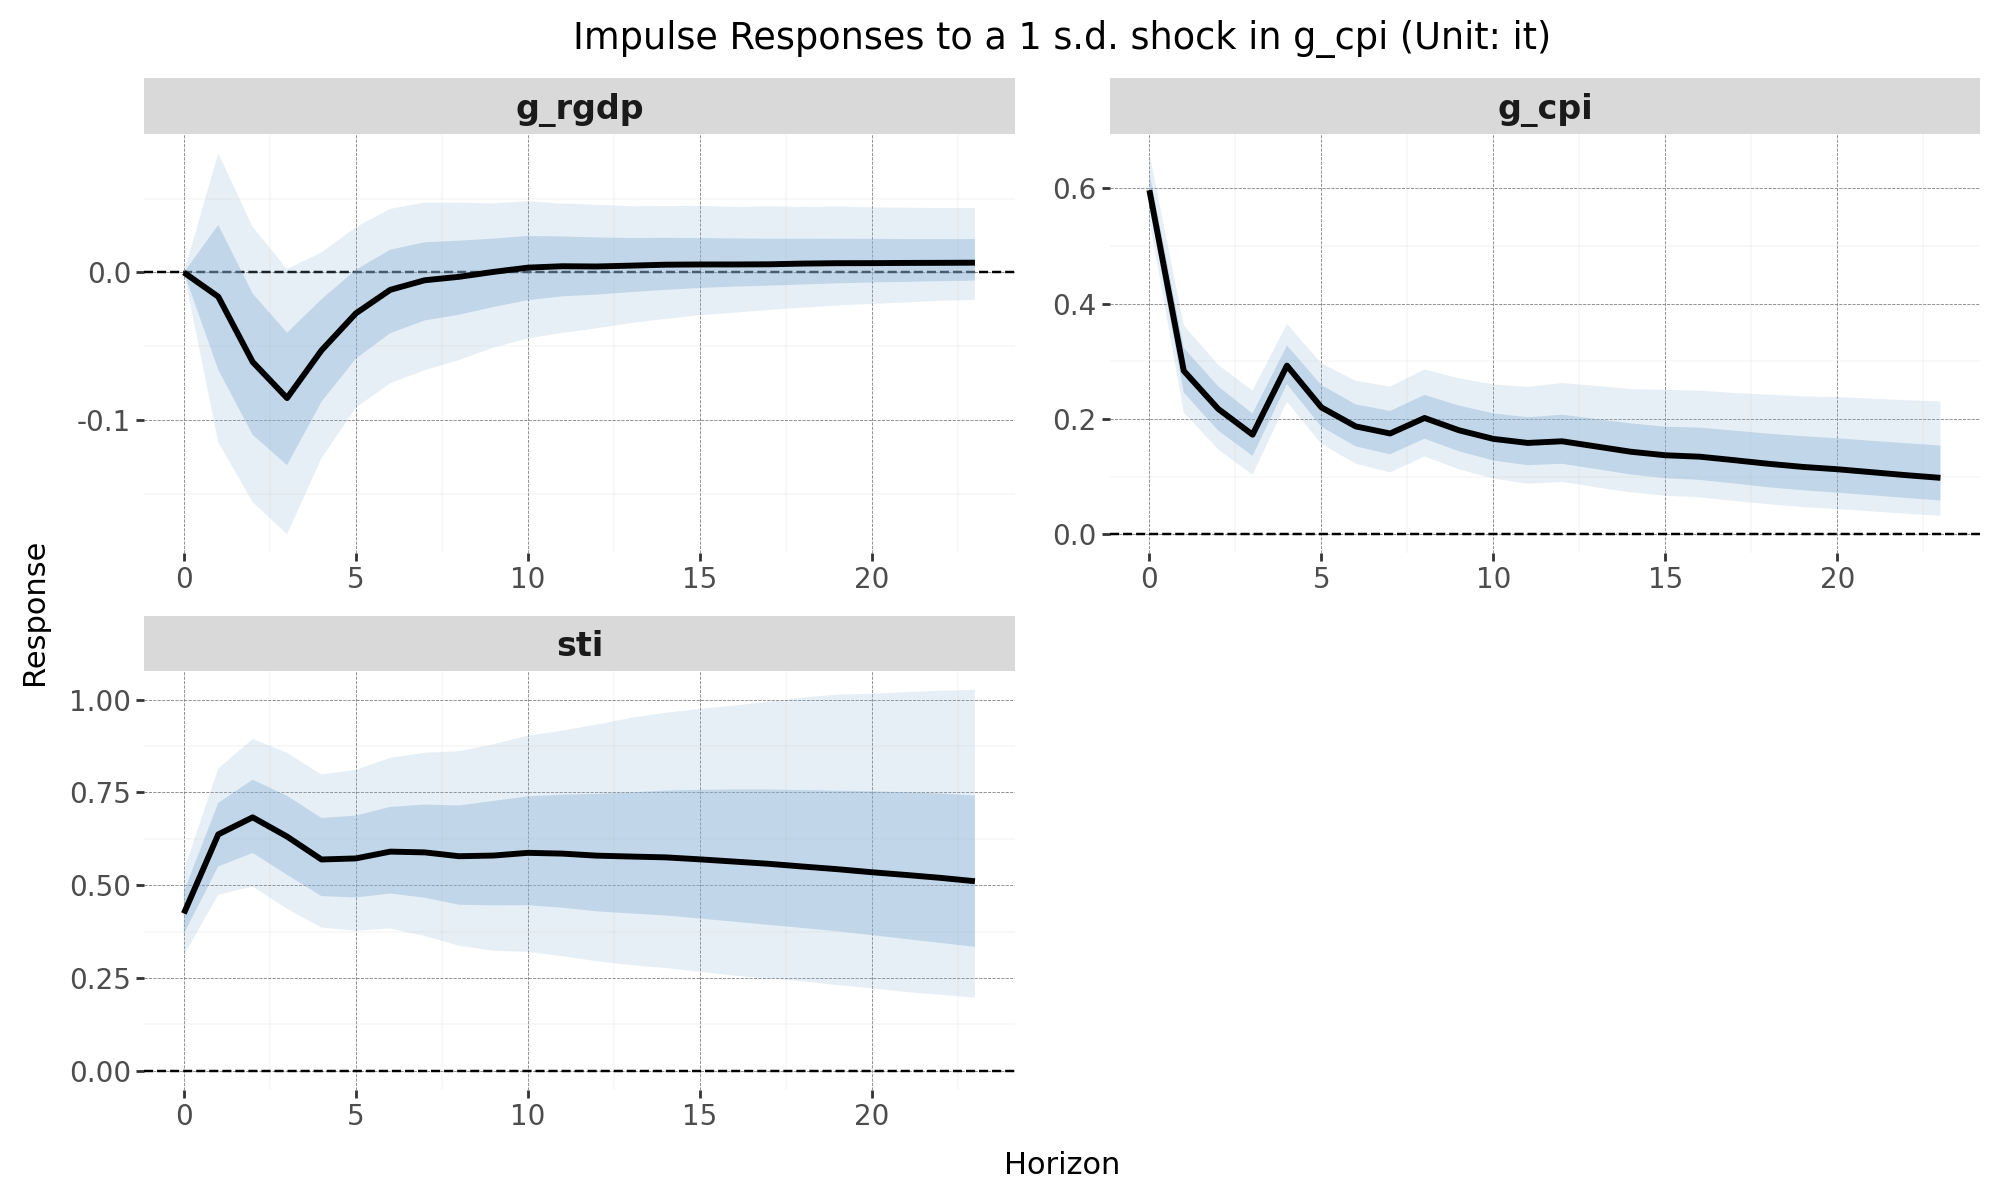

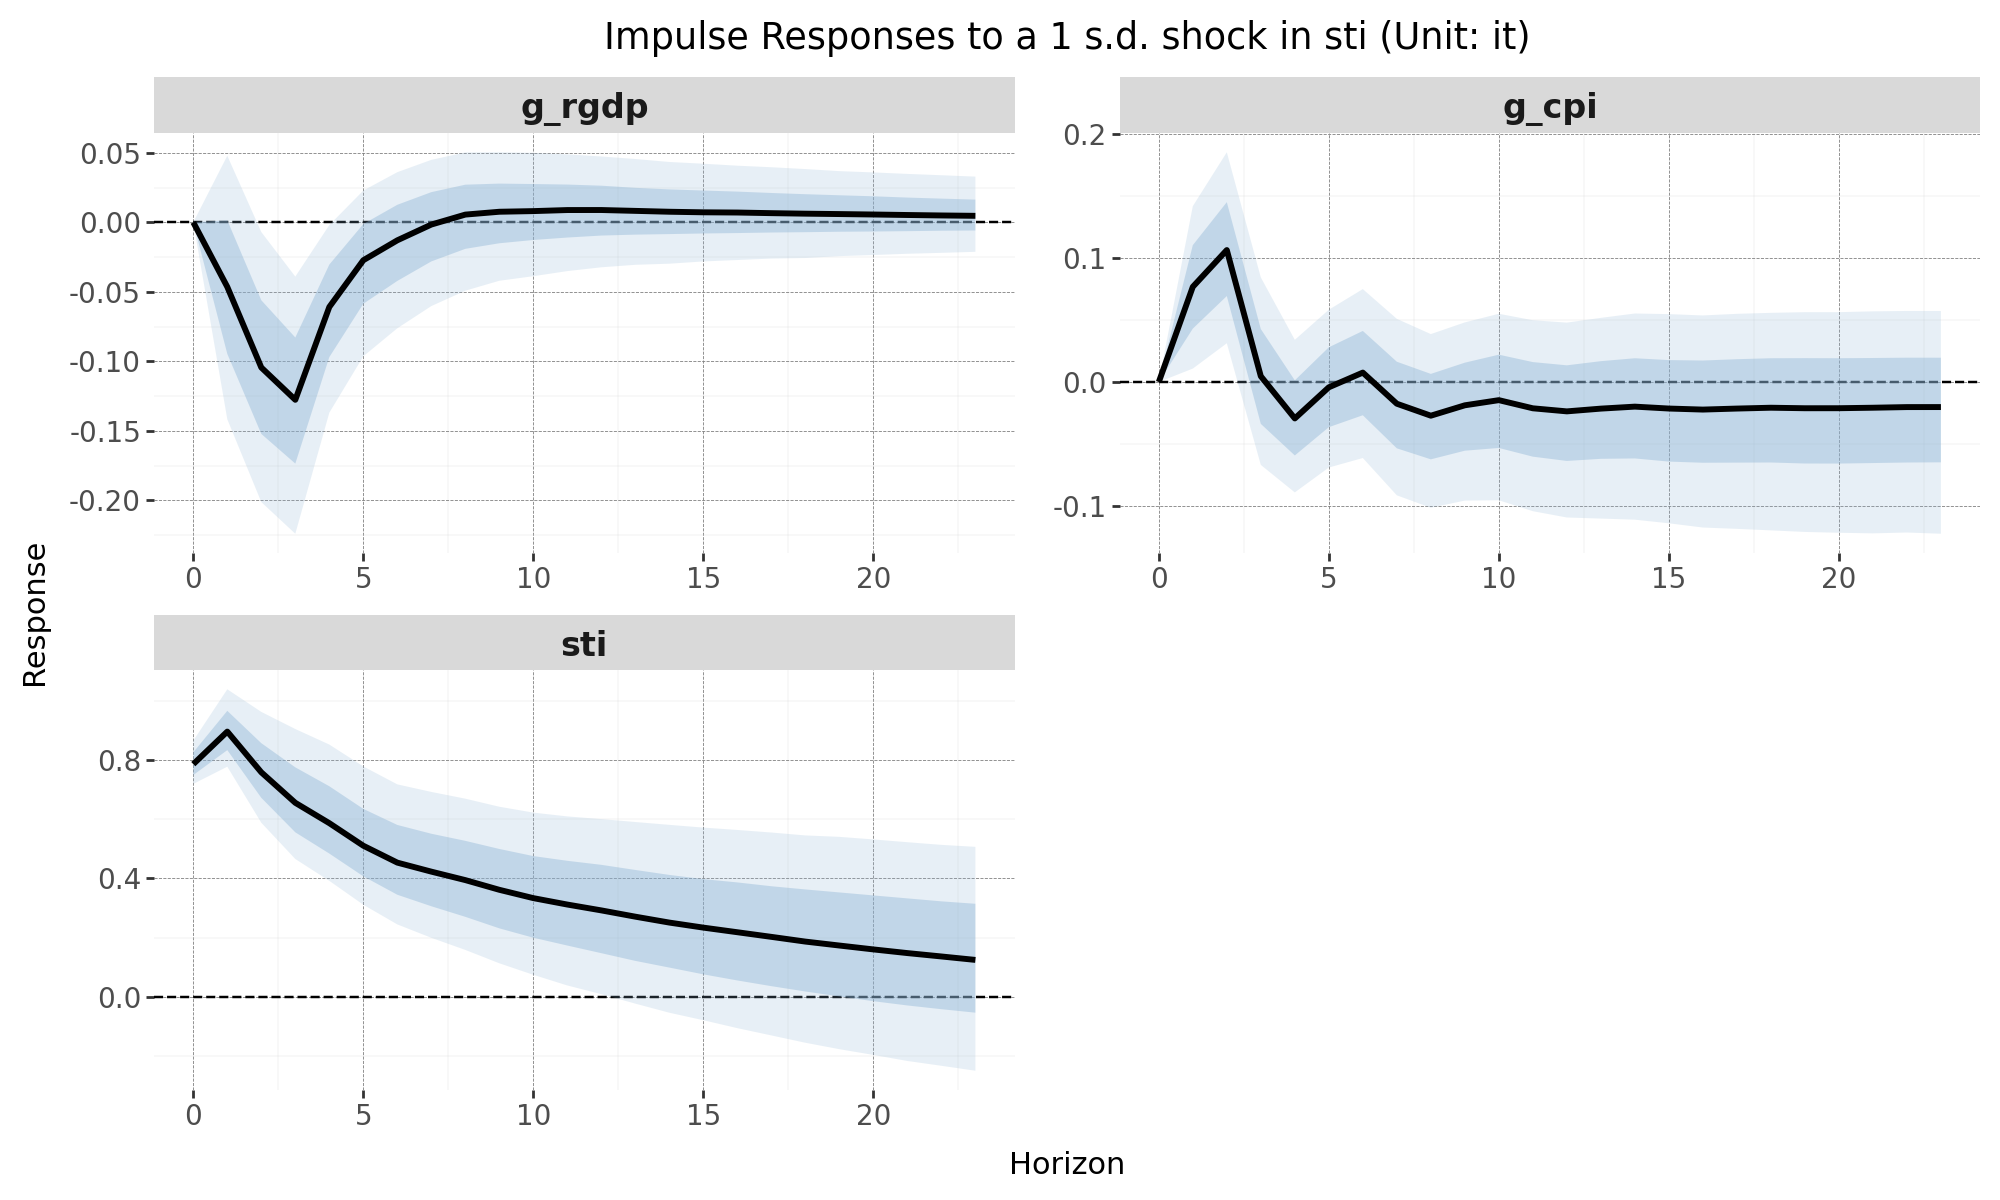

(5000, 24, 4, 3, 3)

In [17]:
irfs = bpvar.compute_irfs(
    plot_irfs=True,
    unit="it",
    cred_interval=[0.68, 0.95],
)

irfs.shape

## 5. Unit-Specific FEVD

Computing Panel FEVD: 100%|██████████| 5000/5000 [00:12<00:00, 387.78it/s]


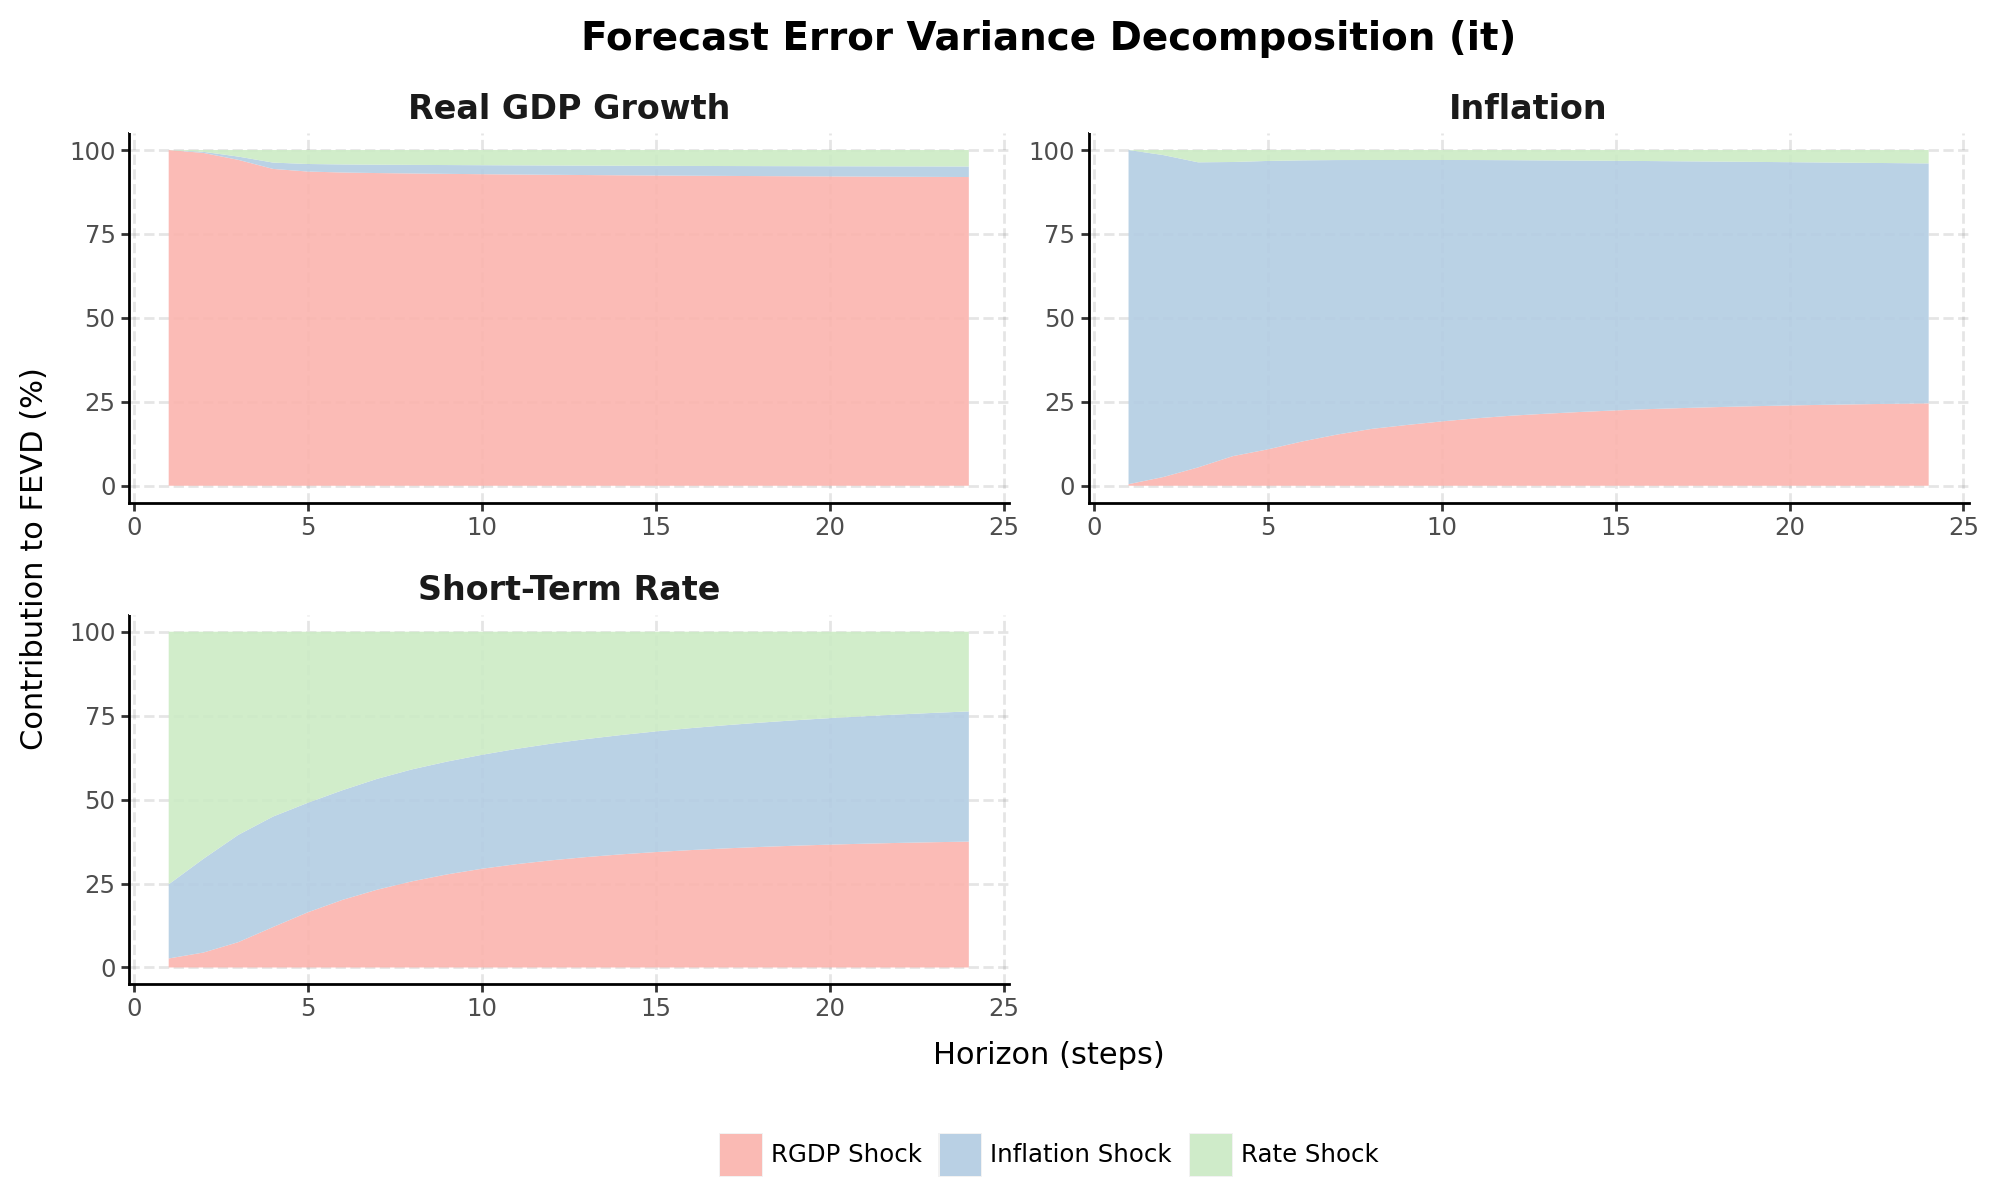

(24, 4, 3, 3)

In [18]:
fevd = bpvar.compute_fevd(
    plot_fevd=True,
    unit="it",
    series_titles=["Real GDP Growth", "Inflation", "Short-Term Rate"],
    shock_titles=["RGDP Shock", "Inflation Shock", "Rate Shock"],
)

fevd["fevd"].shape

## 6. Pooled Mean IRFs and FEVD

Passing `unit="all"` uses the posterior draws of the pooled mean lag coefficients (`bbar_draws`). Since the hierarchical model does not estimate a separate pooled covariance matrix, MacroPy pairs those pooled mean coefficients with the **cross-unit average covariance matrix** in each posterior draw.

Computing Panel IRFs: 100%|██████████| 5000/5000 [00:08<00:00, 594.35it/s]


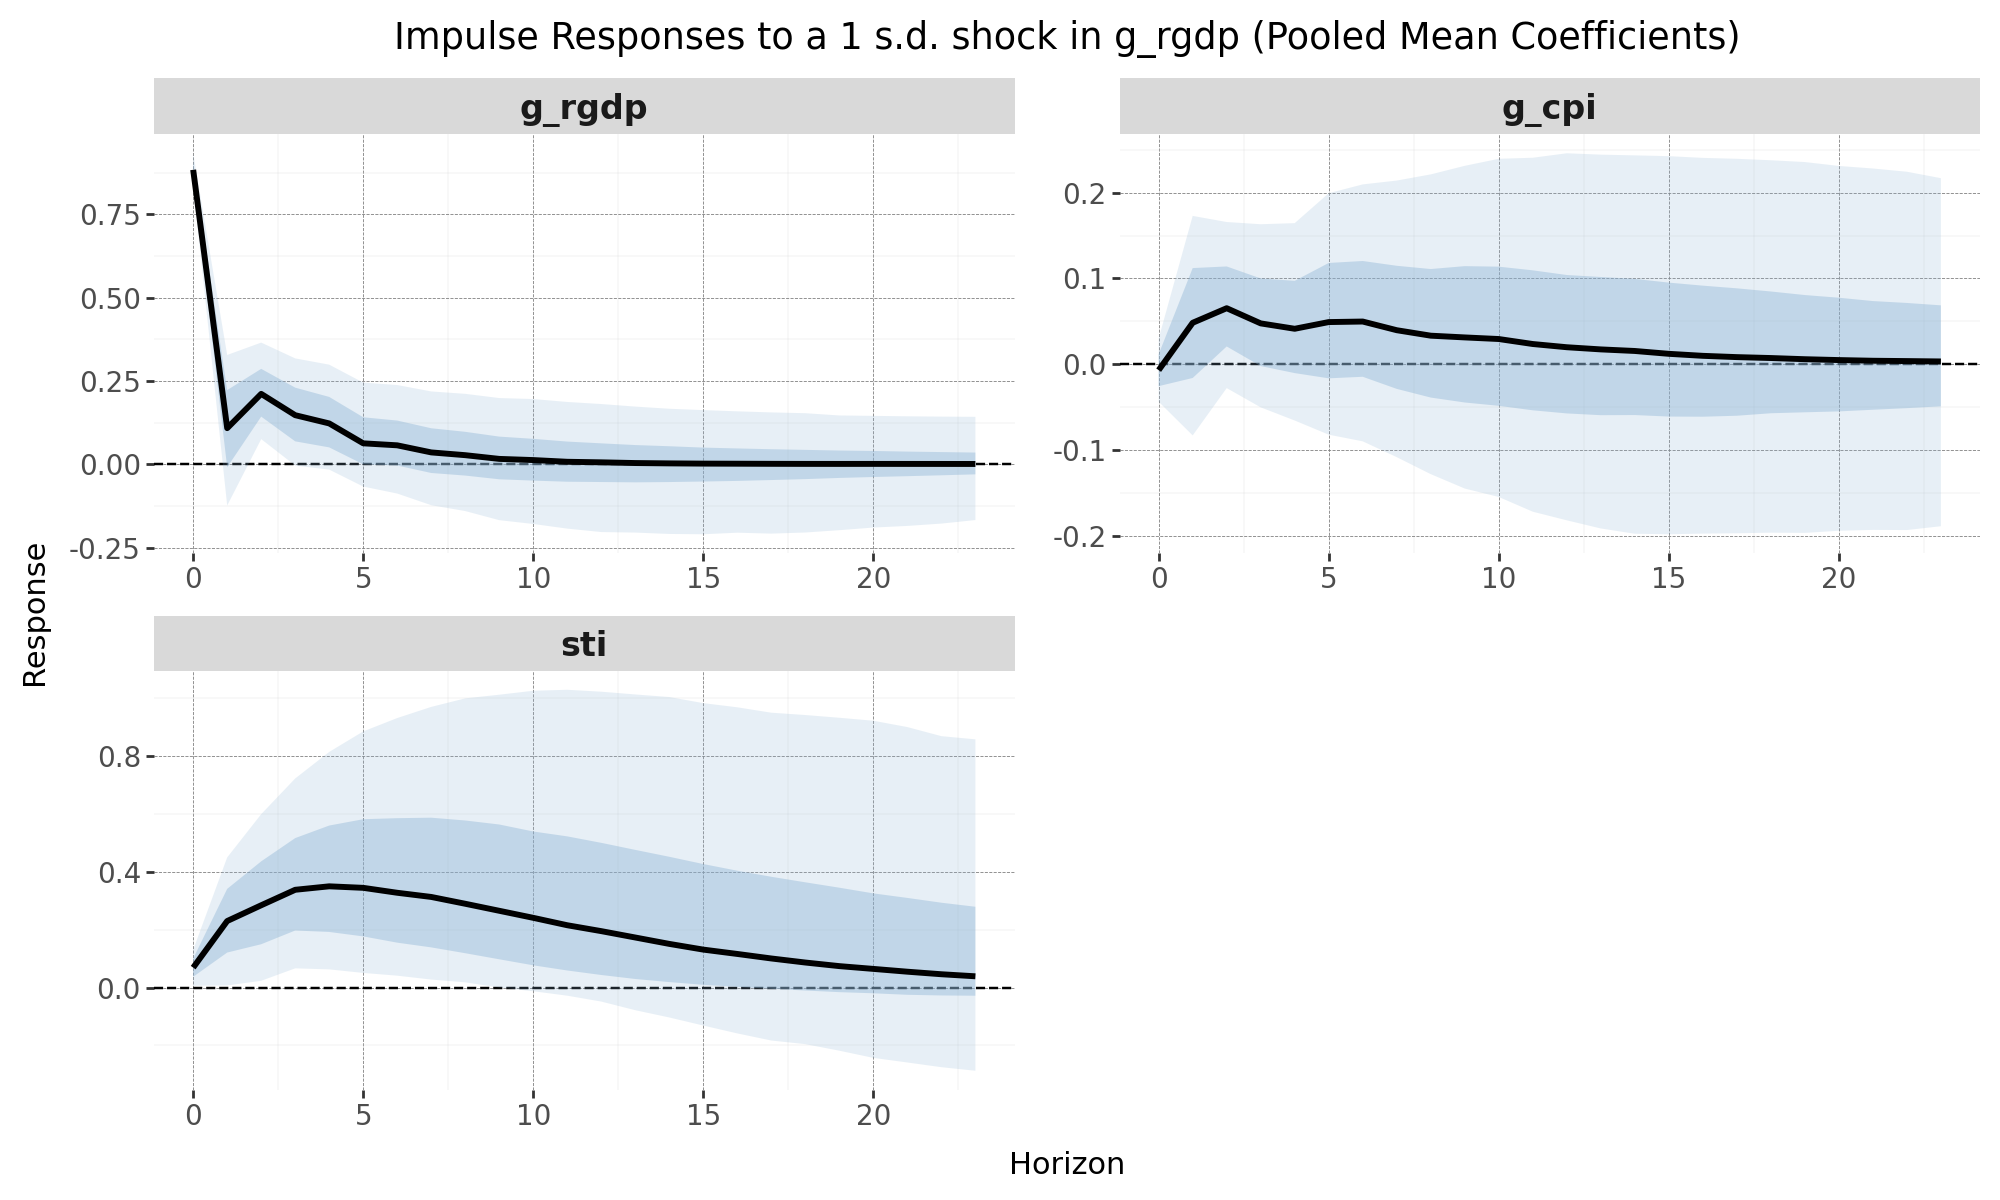

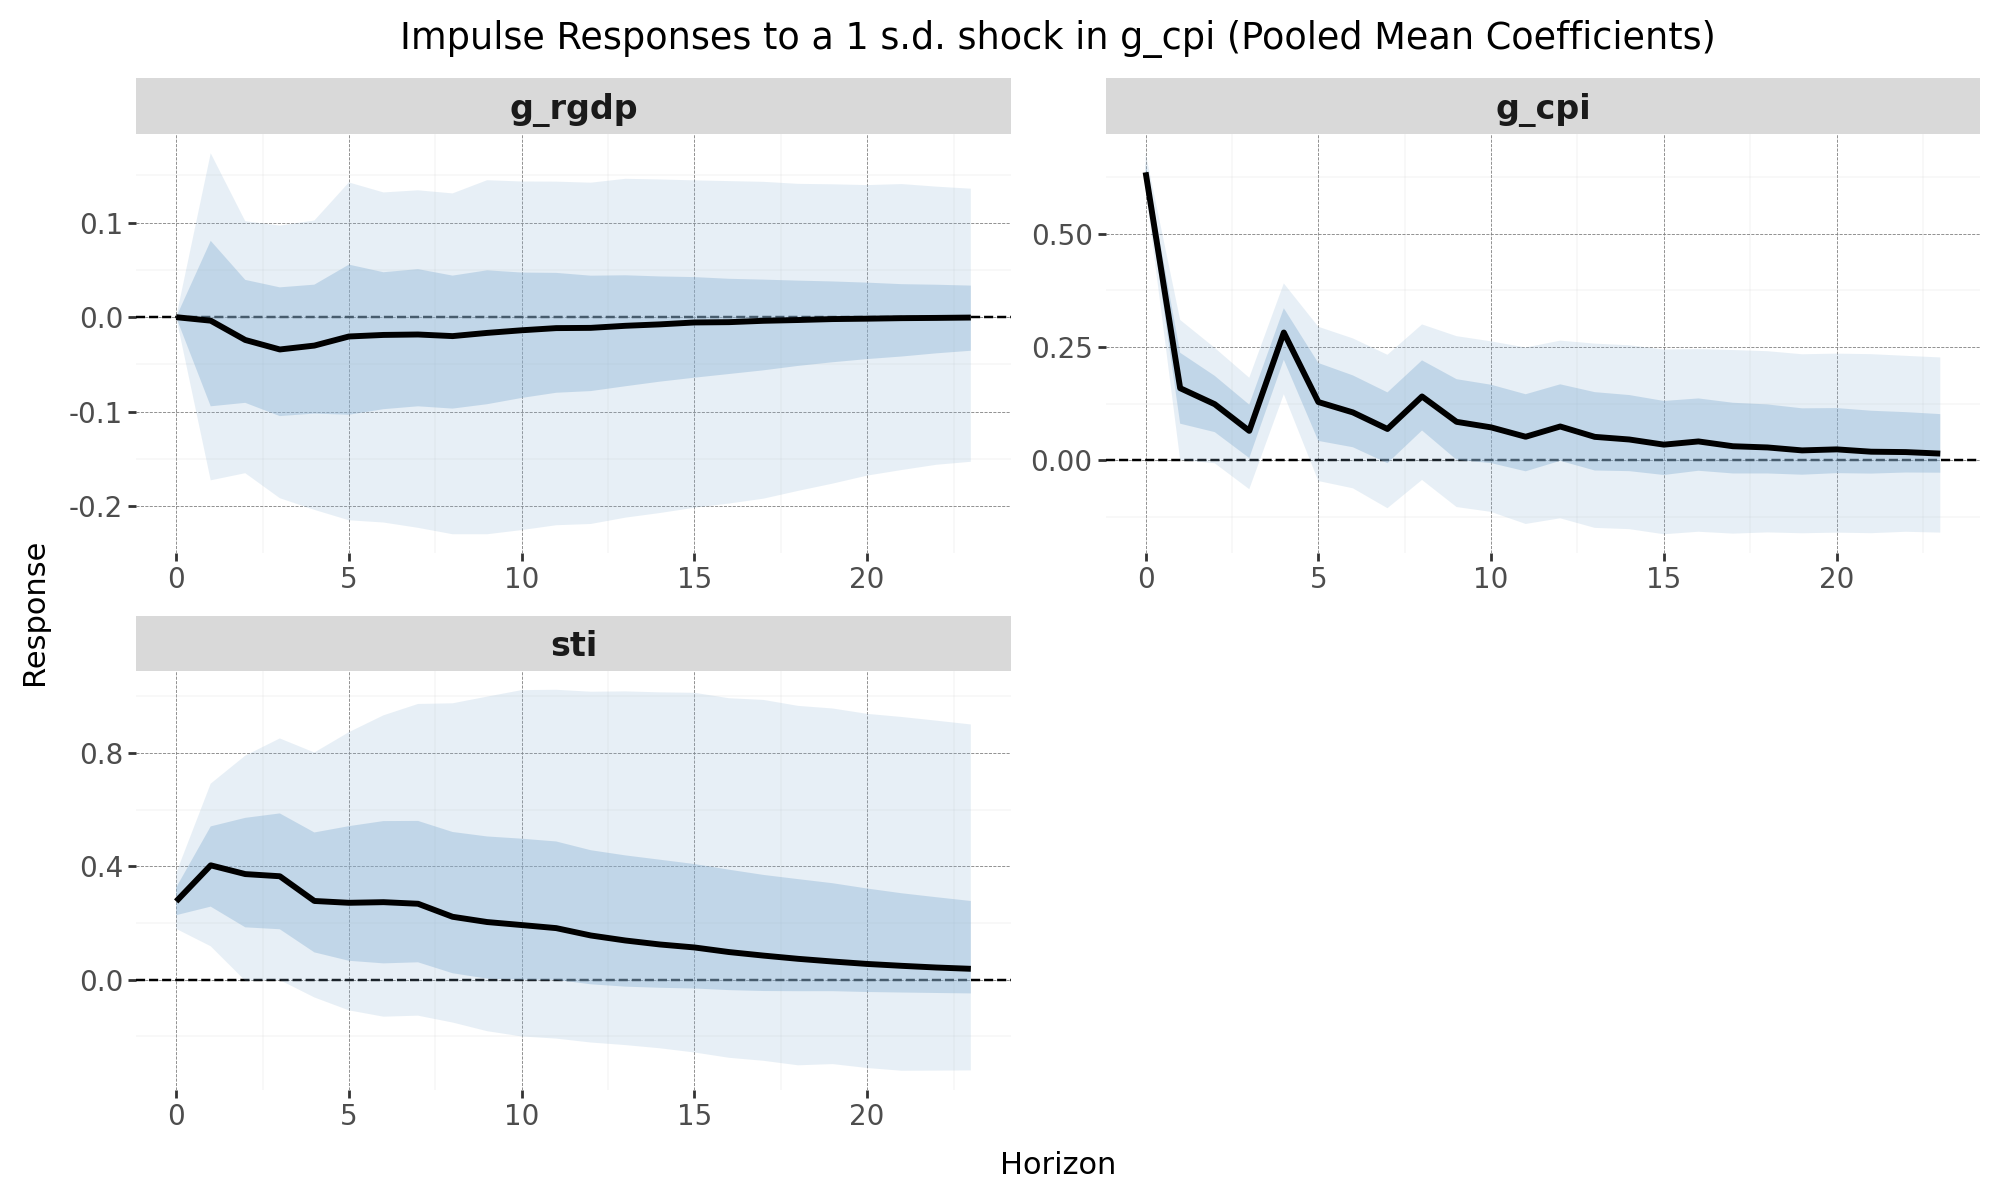

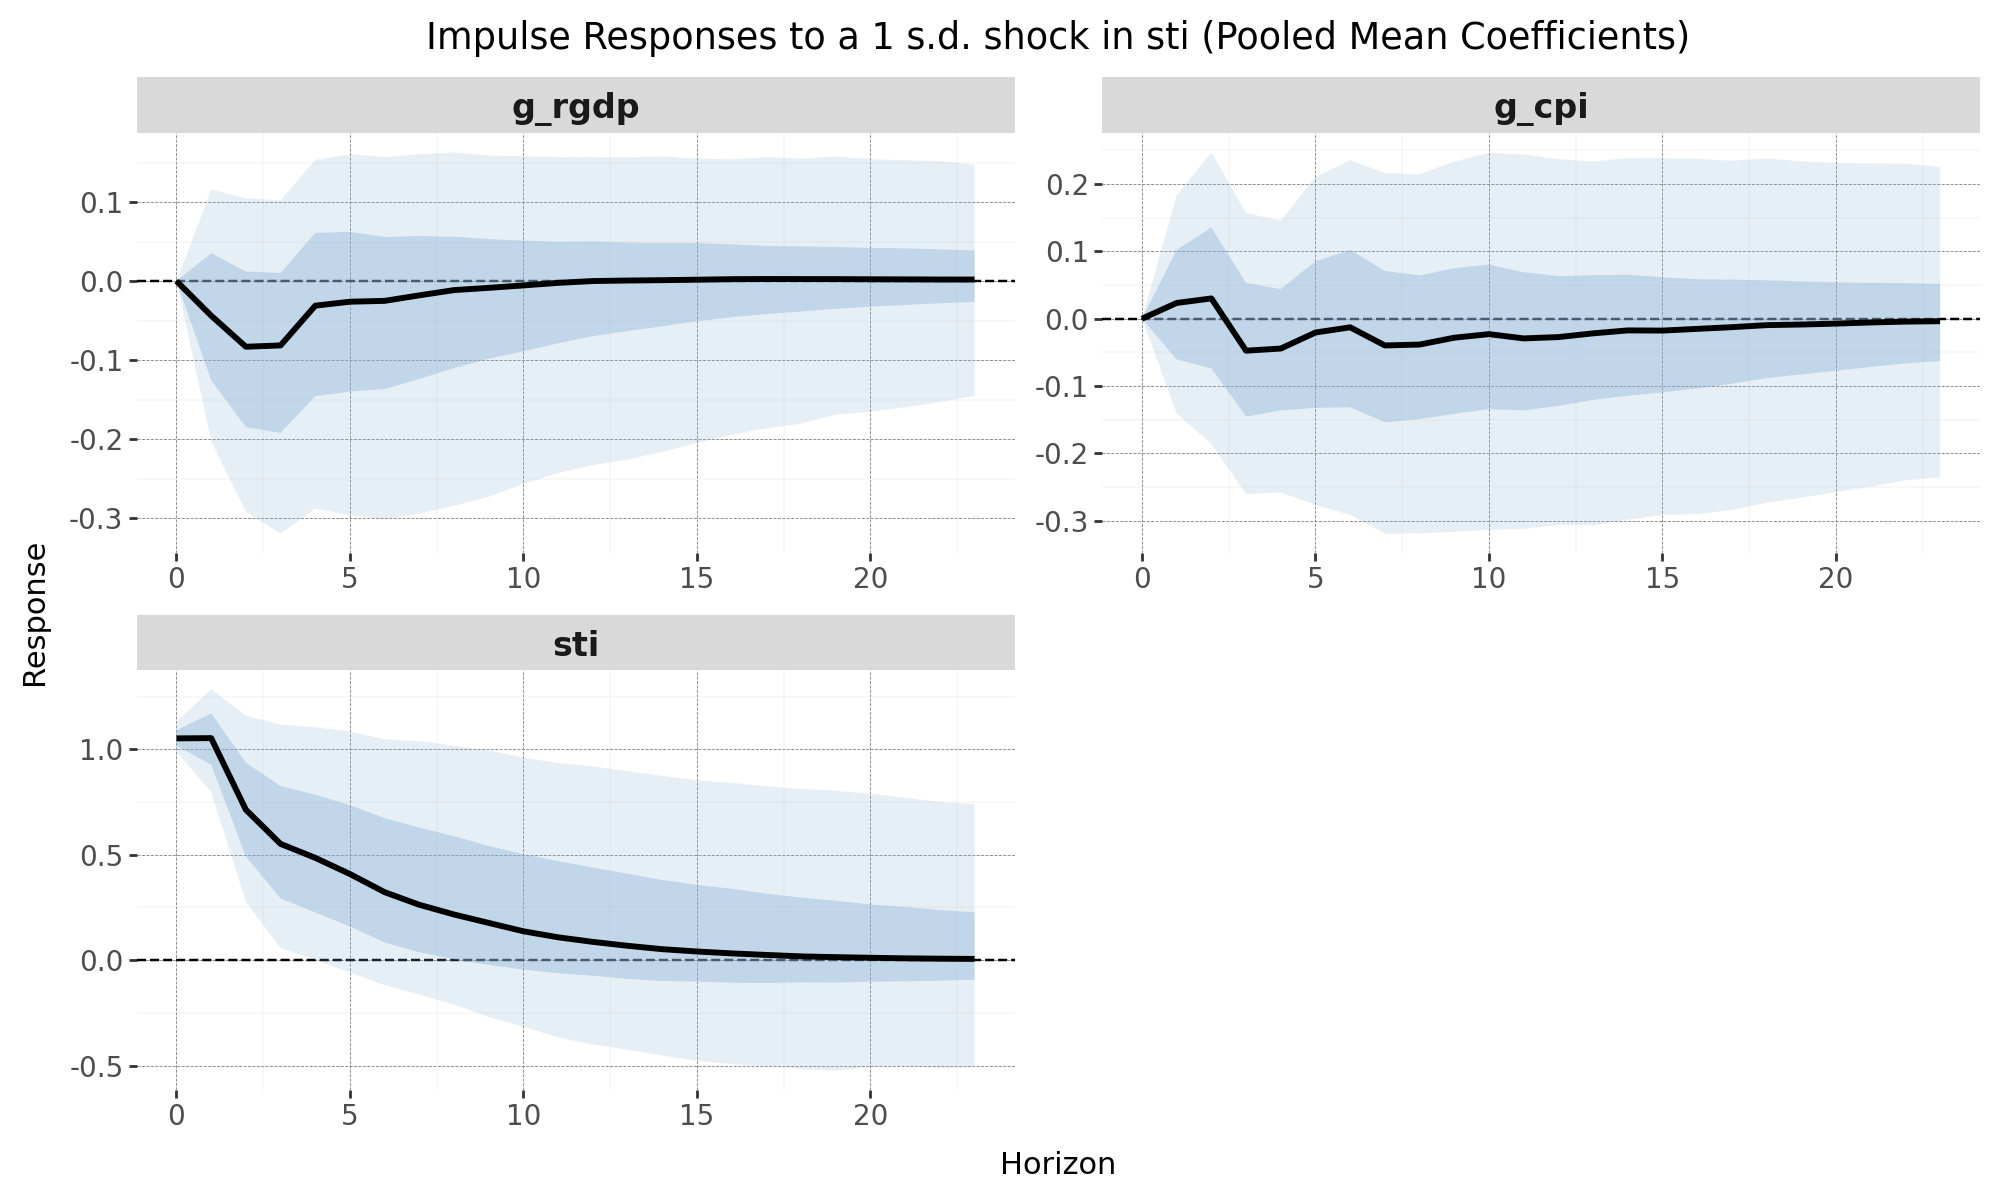

Computing Panel FEVD: 100%|██████████| 5000/5000 [00:12<00:00, 387.34it/s]


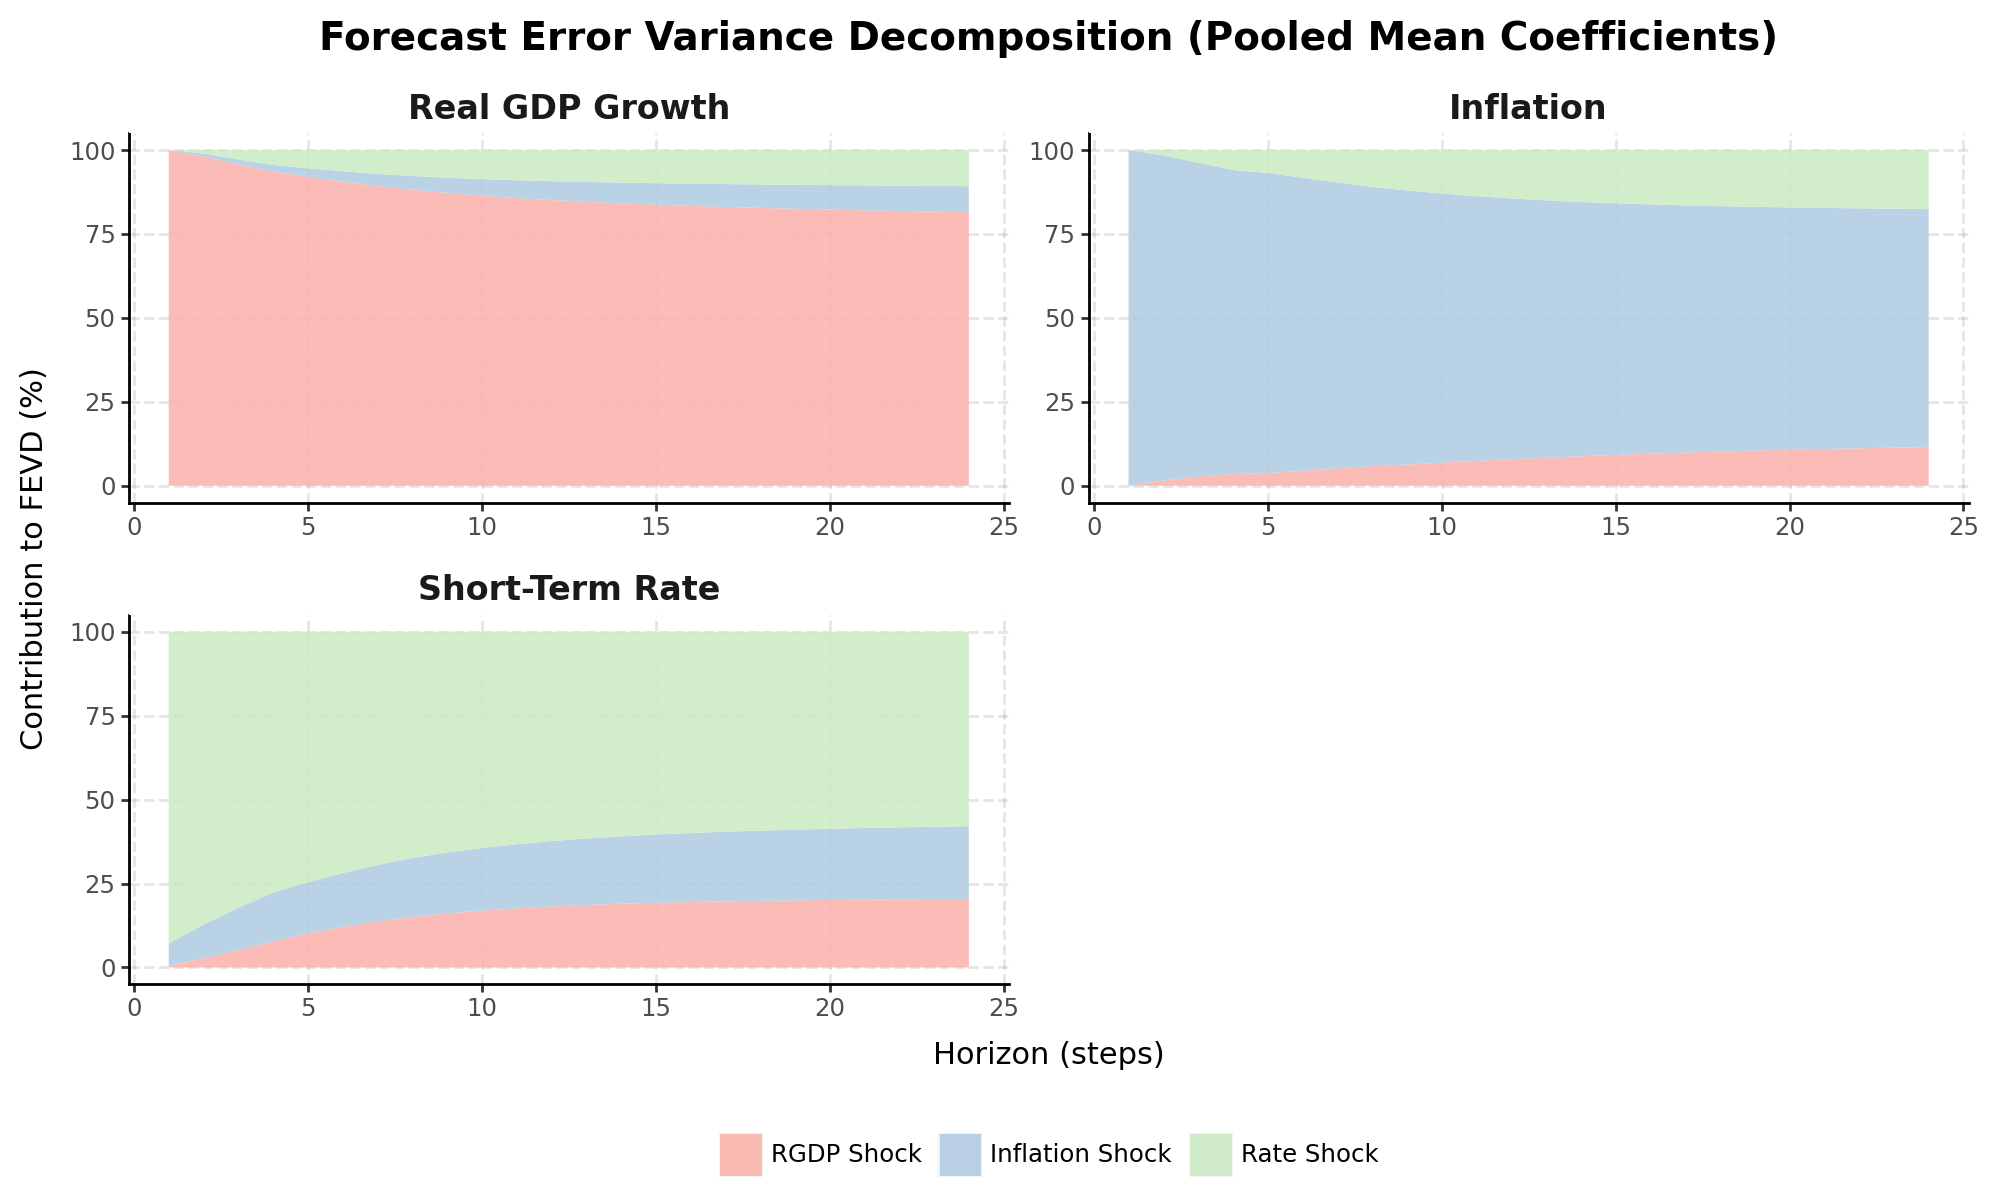

((5000, 24, 3, 3), (24, 3, 3))

In [19]:
pooled_irfs = bpvar.compute_irfs(
    plot_irfs=True,
    unit="all",
    cred_interval=[0.68, 0.95],
)

pooled_fevd = bpvar.compute_fevd(
    plot_fevd=True,
    unit="all",
    series_titles=["Real GDP Growth", "Inflation", "Short-Term Rate"],
    shock_titles=["RGDP Shock", "Inflation Shock", "Rate Shock"],
)

pooled_irfs.shape, pooled_fevd["fevd_pooled"].shape

## 7. Forecasting

Forecasting Panel VAR:   0%|          | 0/5000 [00:00<?, ?it/s]

Forecasting Panel VAR: 100%|██████████| 5000/5000 [00:03<00:00, 1326.39it/s]


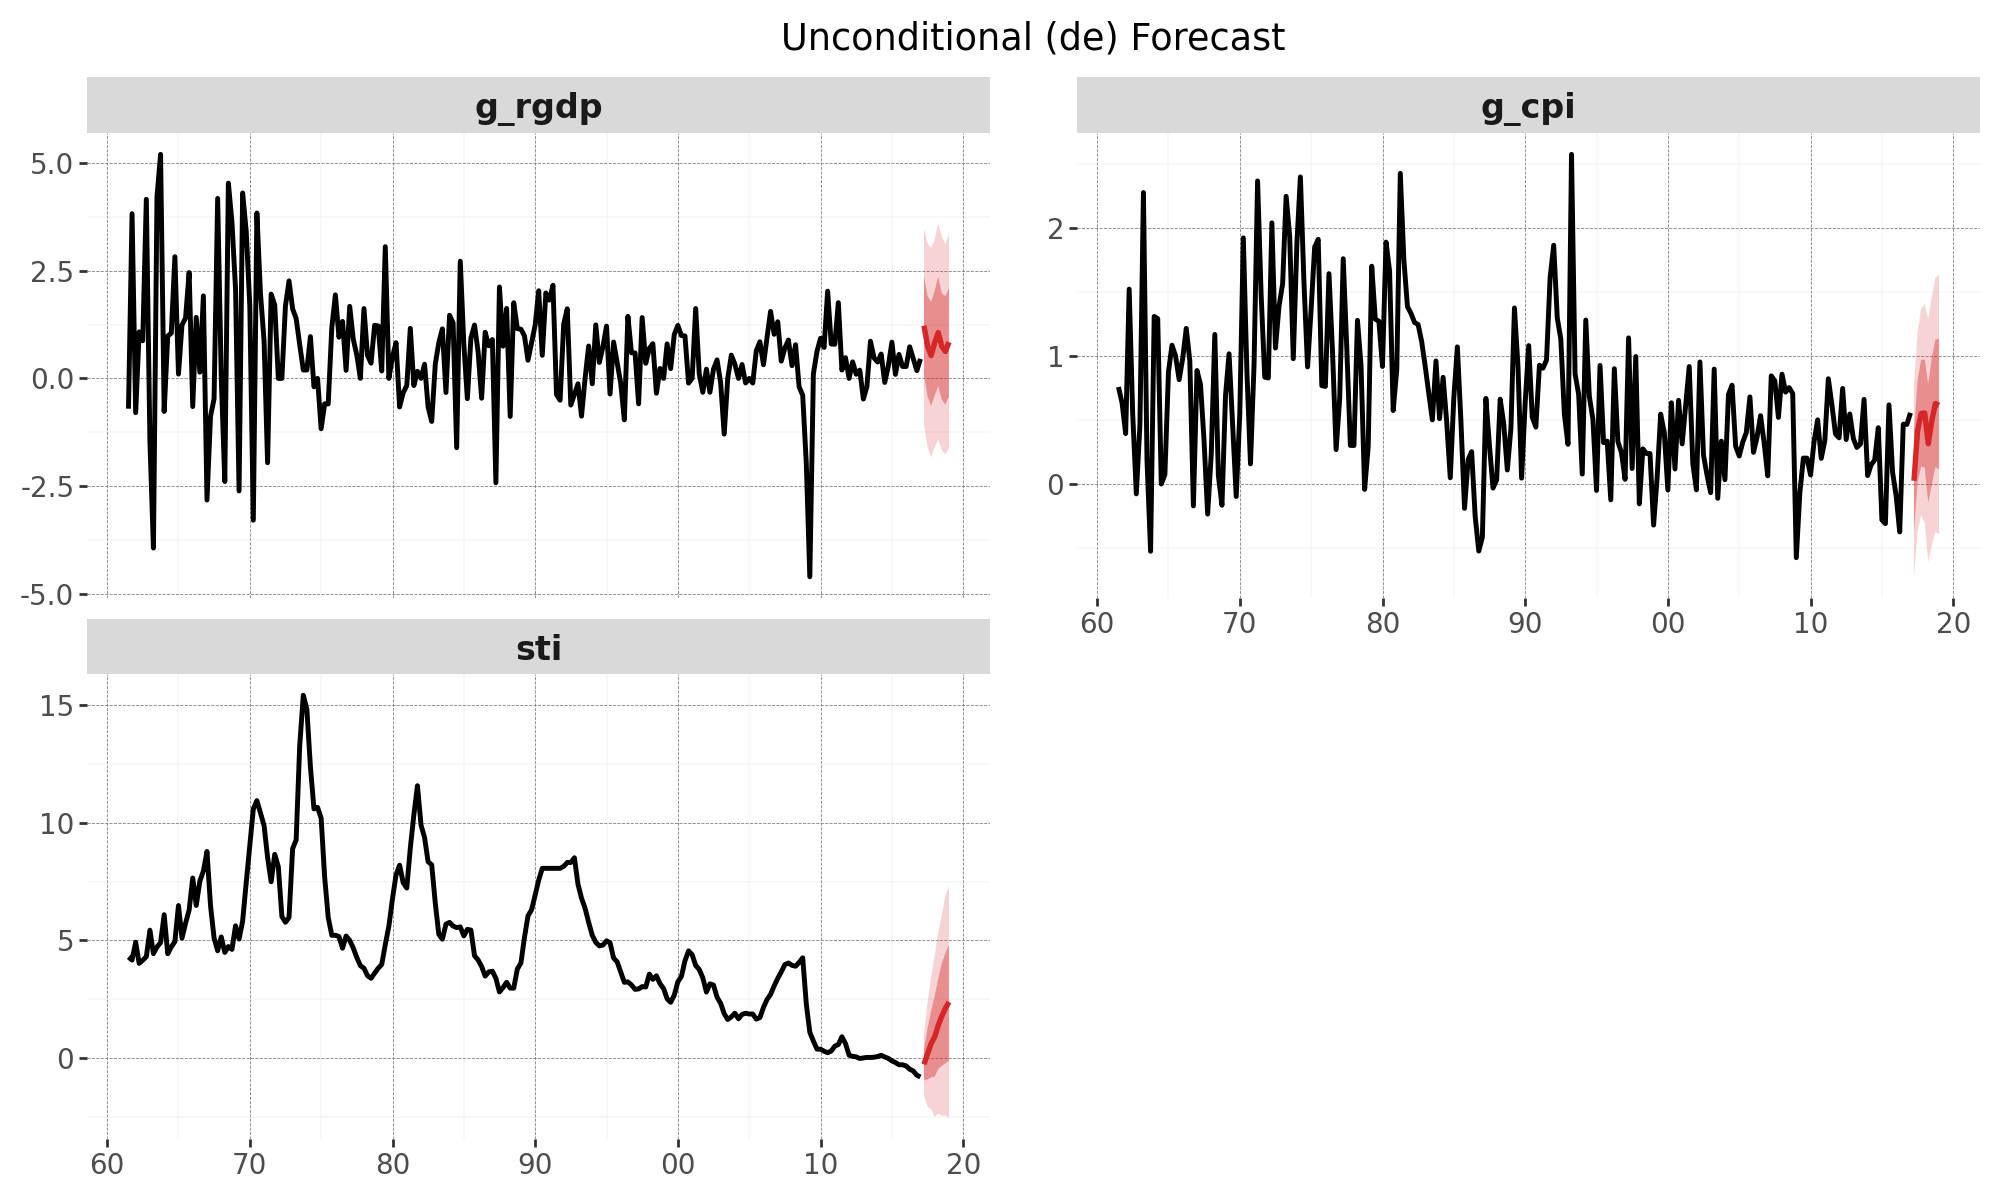

(5000, 8, 4, 3)

In [20]:
future_exog = pd.DataFrame(
    np.repeat(bpvar.common_exog[[-1], :], repeats=8, axis=0),
    columns=bpvar.exo_names,
)

forecasts = bpvar.forecast(
    fhor=8,
    future_exog=future_exog,
    plot_forecast=True,
    unit="de",
    cred_interval=[0.68, 0.95],
)

forecasts["forecast_draws"].shape

## 8. Accessing Unit-Specific Draws

In [21]:
bpvar.units

['de', 'es', 'fr', 'it']

In [22]:
unit_idx = bpvar.units.index("de")
posterior["beta_draws"][:, unit_idx, :].shape

(5000, 36)